In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

base_path = '/content/drive/MyDrive/dataset'

print(f"Checking contents of: {base_path}\n")
if os.path.exists(base_path):
    for item in os.listdir(base_path):
        print(f"- {item}")
else:
    print("Path does not exist! Please check the folder name in your Google Drive.")


Checking contents of: /content/drive/MyDrive/dataset

- msls_metadata.zip
- msls_patch_v1.1.zip
- msls_images_vol_1.zip
- msls_images_vol_2.zip
- msls_images_vol_3.zip
- msls_images_vol_4.zip
- msls_images_vol_5.zip
- msls_images_vol_6.zip
- model level 1
- logs
- triplet_s1.keras
- triplet_final.keras
- triplet_final_best.keras
- triplet_final_v2.keras
- msls
- Level2 model
- model_level_2
- model level 2
- l2_neighborhood_arcface_v3_final.keras
- l2_neighborhood_arcface_v4_stable.keras
- l2_baseline_softmax_secure.keras
- l2_master_stable_checkpoints
- l2_stable_1034_final_checkpoints
- l2_stable_964_checkpoints
- l2_v6_stable_checkpoints
- l2_arcface_702_checkpoints
- l2_arcface_s64_checkpoints
- l2_arcface_phase1_checkpoints
- l2_metric_learning_checkpoints
- faiss_indexes
- l2_metric_learning_checkpoints_phase2
- l2_checkpoints
- faiss_indexes_hybrid
- results_hybrid
- Level 1 arac check


In [ ]:
import os
from google.colab import drive

# تأكد إن الـ Drive mounted
drive.mount('/content/drive', force_remount=False)

CHECKPOINTS_DIR = '/content/drive/MyDrive/dataset/l2_checkpoints'

print("="*55)
print("Checkpoints Available:")
print("="*55)
for f in sorted(os.listdir(CHECKPOINTS_DIR)):
    size = os.path.getsize(os.path.join(CHECKPOINTS_DIR, f))
    print(f"{f:<35} → {size/1024/1024:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints Available:
group1_arc_best.pth                 → 61.8 MB
group1_arc_last.pth                 → 61.8 MB
group1_best.pth                     → 49.4 MB
group2_arc_best.pth                 → 61.8 MB
group2_arc_last.pth                 → 61.8 MB
hybrid_best.pth                     → 58.4 MB
hybrid_epoch16.pth                  → 58.4 MB
hybrid_epoch17.pth                  → 58.4 MB
hybrid_epoch18.pth                  → 58.4 MB
hybrid_epoch19.pth                  → 58.4 MB
hybrid_epoch20.pth                  → 58.4 MB
london_best.pth                     → 42.8 MB


In [ ]:
import os
from pathlib import Path

dataset_path = '/content/drive/MyDrive/dataset'
extract_dir = Path('/content/mapillary_dataset')
extract_dir.mkdir(exist_ok=True)


print(f"Contents of {dataset_path}:")
print("-" * 50)

all_items = os.listdir(dataset_path)
folders = []
files = []

for item in all_items:
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        folders.append(item)
    else:
        files.append(item)

print(f"\n Folders ({len(folders)}):")
for folder in folders:
    print(f"  - {folder}/")

print(f"\n📄 Files ({len(files)}):")
for file in files:
    file_path = os.path.join(dataset_path, file)
    size_mb = os.path.getsize(file_path) / (1024**2)
    size_display = f"{size_mb:.1f} MB" if size_mb < 1000 else f"{size_mb/1024:.2f} GB"
    print(f"  - {file} ({size_display})")


zip_files = [f for f in files if f.endswith('.zip')]
print(f"\n🔍 Found {len(zip_files)} zip files:")
for zf in zip_files:
    zf_path = os.path.join(dataset_path, zf)
    size_gb = os.path.getsize(zf_path) / (1024**3)
    print(f"  - {zf} ({size_gb:.2f} GB)")

Contents of /content/drive/MyDrive/dataset:
--------------------------------------------------

 Folders (20):
  - model level 1/
  - logs/
  - msls/
  - Level2 model/
  - model_level_2/
  - model level 2/
  - l2_master_stable_checkpoints/
  - l2_stable_1034_final_checkpoints/
  - l2_stable_964_checkpoints/
  - l2_v6_stable_checkpoints/
  - l2_arcface_702_checkpoints/
  - l2_arcface_s64_checkpoints/
  - l2_arcface_phase1_checkpoints/
  - l2_metric_learning_checkpoints/
  - faiss_indexes/
  - l2_metric_learning_checkpoints_phase2/
  - l2_checkpoints/
  - faiss_indexes_hybrid/
  - results_hybrid/
  - Level 1 arac check/

📄 Files (15):
  - msls_metadata.zip (172.4 MB)
  - msls_patch_v1.1.zip (0.1 MB)
  - msls_images_vol_1.zip (10.28 GB)
  - msls_images_vol_2.zip (10.29 GB)
  - msls_images_vol_3.zip (10.24 GB)
  - msls_images_vol_4.zip (10.25 GB)
  - msls_images_vol_5.zip (10.13 GB)
  - msls_images_vol_6.zip (1.52 GB)
  - triplet_s1.keras (140.7 MB)
  - triplet_final.keras (491.5 MB)
  - t

In [ ]:
import zipfile


metadata_zip = None
for zf in zip_files:
    if 'metadata' in zf.lower() or 'msls_metadata' in zf.lower():
        metadata_zip = zf
        break

if metadata_zip:
    metadata_path = os.path.join(dataset_path, metadata_zip)
    print(f"Extracting metadata from: {metadata_zip}")

    with zipfile.ZipFile(metadata_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print(" Metadata extracted successfully!")


    print("\nExtracted contents:")
    for item in list(extract_dir.iterdir())[:10]:
        if item.is_dir():
            print(f"  📁 {item.name}/")
        else:
            size_kb = item.stat().st_size / 1024
            print(f"  📄 {item.name} ({size_kb:.1f} KB)")
else:
    print("No metadata zip file found. Checking all zip files...")
    if zip_files:
        print(f"Available zip files: {zip_files}")
    else:
        print("No zip files found in the dataset folder!")

Extracting metadata from: msls_metadata.zip
 Metadata extracted successfully!

Extracted contents:
  📁 train_val/
  📁 test/


In [ ]:

image_volumes = [zf for zf in zip_files if zf != metadata_zip]

print(f"Found {len(image_volumes)} image volumes to extract:")
for i, vol in enumerate(image_volumes, 1):
    vol_path = os.path.join(dataset_path, vol)
    size_gb = os.path.getsize(vol_path) / (1024**3)
    print(f"  {i}. {vol} ({size_gb:.2f} GB)")


!df -h /content


proceed = input("\nProceed with extraction? (yes/no): ")
if proceed.lower() == 'yes':
    for i, vol in enumerate(image_volumes, 1):
        vol_path = os.path.join(dataset_path, vol)
        print(f"\n[{i}/{len(image_volumes)}] Extracting {vol}...")

        try:
            with zipfile.ZipFile(vol_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print(f"   Completed")


            file_count = len(list(extract_dir.rglob('*')))
            print(f"  Total files so far: {file_count}")

        except Exception as e:
            print(f"   Error: {e}")
            break

    print("\n All extractions completed!")


    image_files = list(extract_dir.rglob('*.jpg')) + list(extract_dir.rglob('*.png'))
    print(f"\nTotal image files extracted: {len(image_files)}")

    if len(image_files) > 0:
        print(f"Example images:")
        for img in image_files[:5]:
            print(f"  - {img.relative_to(extract_dir)}")
else:
    print("Extraction cancelled.")

Found 7 image volumes to extract:
  1. msls_patch_v1.1.zip (0.00 GB)
  2. msls_images_vol_1.zip (10.28 GB)
  3. msls_images_vol_2.zip (10.29 GB)
  4. msls_images_vol_3.zip (10.24 GB)
  5. msls_images_vol_4.zip (10.25 GB)
  6. msls_images_vol_5.zip (10.13 GB)
  7. msls_images_vol_6.zip (1.52 GB)
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   45G  192G  19% /

Proceed with extraction? (yes/no): yes

[1/7] Extracting msls_patch_v1.1.zip...
   Completed
  Total files so far: 3961

[2/7] Extracting msls_images_vol_1.zip...
   Completed
  Total files so far: 300637

[3/7] Extracting msls_images_vol_2.zip...
   Completed
  Total files so far: 578142

[4/7] Extracting msls_images_vol_3.zip...
   Completed
  Total files so far: 885211

[5/7] Extracting msls_images_vol_4.zip...
   Completed
  Total files so far: 1159819

[6/7] Extracting msls_images_vol_5.zip...
   Completed
  Total files so far: 1494198

[7/7] Extracting msls_images_vol_6.zip...
   Completed
  Total fil

In [ ]:
import zipfile
import os

metadata_zip_path = '/content/drive/MyDrive/dataset/msls_metadata.zip'
extract_to = '/content/drive/MyDrive/dataset/msls'

if os.path.exists(metadata_zip_path):
    print("Found metadata zip! Extracting...")
    with zipfile.ZipFile(metadata_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(" Metadata extracted successfully!")
else:
    print(f" Cannot find {metadata_zip_path}. Please check the file name and path.")

Found metadata zip! Extracting...
 Metadata extracted successfully!


In [ ]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

def get_detailed_metadata(extract_dir):
    extract_dir = Path(extract_dir)
    metadata_root = extract_dir / 'msls_metadata'
    data_list = []

    # القواميس دي لتخزين معلومات المدن من الـ Metadata
    city_info = []

    for split in ['test', 'train_val']:
        split_path = metadata_root / split
        if not split_path.exists(): continue

        for city_folder in split_path.iterdir():
            if city_folder.is_dir():
                # قراءة ملف الـ raw.csv لكل مدينة لجلب الـ Metadata الحقيقية
                raw_csv = city_folder / 'raw.csv'
                if raw_csv.exists():
                    temp_df = pd.read_csv(raw_csv)

                    # تجميع معلومات الجدول المطلوب
                    city_info.append({
                        'City': city_folder.name,
                        'Split': split,
                        'DB Images': len(temp_df[temp_df['night'] == False]), # مثال للتصنيف
                        'Query Images': len(temp_df[temp_df['night'] == True]),
                        'Continent': 'N/A', # يمكن استخراجها من ملفات التوزيع الجغرافي لو متاحة
                        'Environment': 'Urban/Suburban'
                    })

                    # ربط مسارات الصور الفعلية
                    img_dir = extract_dir / split / city_folder.name / "images"
                    if img_dir.exists():
                        for img in img_dir.glob("*.jpg"):
                            data_list.append({
                                'image_path': str(img),
                                'city': city_folder.name.lower(),
                                'label': 0 # سيتم تحديثه بـ LabelEncoder
                            })

    df_meta = pd.DataFrame(city_info)
    df_imgs = pd.DataFrame(data_list)
    return df_meta, df_imgs

# تنفيذ الربط
# df_summary, df_main = get_detailed_metadata('/content/mapillary_dataset')
# display(df_summary) # هيعرض الجدول اللي طلبته


In [ ]:
import os
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

def build_msls_dataframe(root_path):
    root = Path(root_path)
    all_images = []

    # هنمشي جوه كل المجلدات وندور على أي jpg أو png
    print("Searching for images... this might take a minute.")
    for img_path in root.rglob("*.jpg"):
        # استخراج اسم المدينة: MSLS هيكلها عادة يكون .../split/city/images/file.jpg
        # فاحنا هناخد المجلد اللي قبل images
        parts = img_path.parts
        if "images" in parts:
            city_index = parts.index("images") - 1
            city_name = parts[city_index].lower()
            split = parts[city_index - 1] if city_index > 0 else "unknown"

            all_images.append({
                'image_path': str(img_path),
                'city': city_name,
                'split': split
            })

    df = pd.DataFrame(all_images)
    return df

# 1. تجميع البيانات
df_main = build_msls_dataframe('/content/mapillary_dataset')

if df_main.empty:
    print(" No images found! Please check if /content/mapillary_dataset contains the extracted folders.")
else:
    # 2. عمل الـ Summary Table
    df_summary = df_main.groupby(['city', 'split']).size().reset_index(name='Total Images')

    # 3. تجهيز الـ Labels (الـ 30 مدينة)
    le = LabelEncoder()
    df_main['label'] = le.fit_transform(df_main['city'])

    print(f" Found {len(df_main)} images.")
    print(f" Total Unique Cities: {df_main['city'].nunique()}")

    # عرض الجدول
    import IPython
    display(IPython.display.HTML("<h3>MSLS Dataset Summary</h3>"))
    display(df_summary)

    # 4. طباعة عينة للتأكد
    print("\nSample Path:", df_main['image_path'].iloc[0])


Searching for images... this might take a minute.
 Found 1530160 images.
 Total Unique Cities: 2


,city,split,Total Images
0,database,amman,953
1,database,amsterdam,11539
2,database,athens,3355
3,database,austin,28462
4,database,bangkok,74620
5,database,bengaluru,11731
6,database,berlin,42965
7,database,boston,14024
8,database,budapest,153321
9,database,buenosaires,3710



Sample Path: /content/mapillary_dataset/train_val/trondheim/query/images/cjRmGiect0Ob6JU5f3uHnw.jpg


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_summary)

https://docs.google.com/spreadsheets/d/1EKhCD7OOCzlmPBCb7pGt1SW-ek7XHIG5_MIJESpZyLg/edit#gid=0


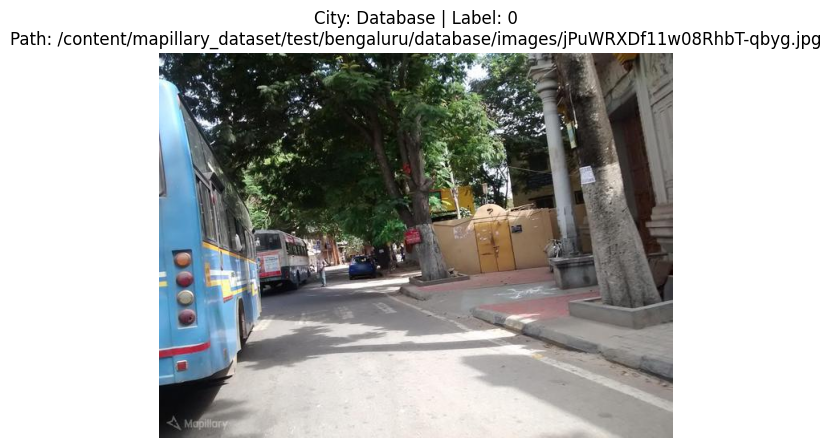

In [ ]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch

# 1. الـ Normalization والـ Augmentation للوصول لـ 97%
# أضفت RandomHorizontalFlip و ColorJitter للتعامل مع اختلاف الإضاءة في MSLS
train_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. وظيفة لعرض صورة من الداتاسيت للتأكد من الـ Path والـ Label
def preview_sample(df, idx=0):
    img_path = df.iloc[idx]['image_path']
    city = df.iloc[idx]['city']
    label = df.iloc[idx]['label']

    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title(f"City: {city.capitalize()} | Label: {label}\nPath: {img_path}")
    plt.axis('off')
    plt.show()

# عرض عينة عشوائية
import random
preview_sample(df_main, idx=random.randint(0, len(df_main)-1))


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. تقسيم البيانات مع الحفاظ على تمثيل الـ 30 مدينة (Stratify)
train_df, val_df = train_test_split(
    df_main,
    test_size=0.2,
    stratify=df_main['city'],
    random_state=42
)

# 2. حساب الأوزان لكل مدينة لتعويض المدن الصغيرة (Nairobi, Amman)
city_counts = train_df['city'].value_counts()
weights = 1.0 / city_counts
sample_weights = train_df['city'].map(weights).values

# 3. إنشاء الـ Sampler لضمان رؤية الـ 30 مدينة بالتساوي
from torch.utils.data import WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f" Split Complete:")
print(f"   Train samples: {len(train_df)}")
print(f"   Val samples: {len(val_df)}")
print(f"   Cities in Train: {train_df['city'].nunique()}")


 Split Complete:
   Train samples: 1224128
   Val samples: 306032
   Cities in Train: 2


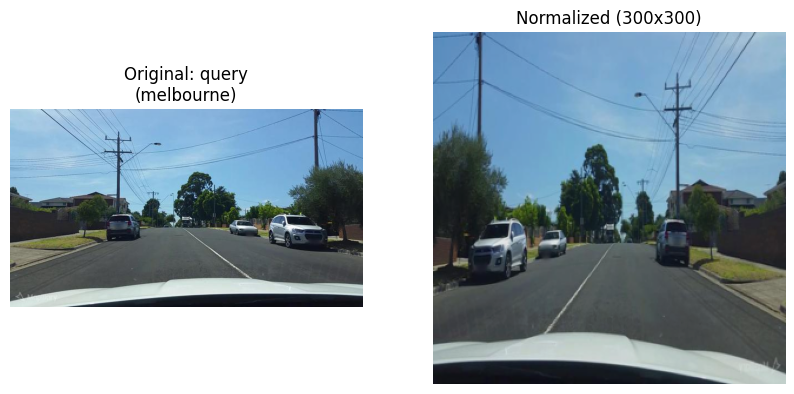

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def preview_dataset(df, transform=None):
    # اختيار عينة عشوائية
    idx = random.randint(0, len(df)-1)
    row = df.iloc[idx]

    img = Image.open(row['image_path']).convert('RGB')

    plt.figure(figsize=(10, 5))

    # الصورة الأصلية
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original: {row['city']}\n({row['split']})")
    plt.axis('off')

    # الصورة بعد الـ Pre-processing (Normalization)
    if transform:
        img_t = transform(img)
        # إعادة الصورة لأصلها للعرض فقط (Denormalize)
        img_display = img_t.permute(1, 2, 0).numpy()
        img_display = (img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img_display = np.clip(img_display, 0, 1)

        plt.subplot(1, 2, 2)
        plt.imshow(img_display)
        plt.title("Normalized (300x300)")
        plt.axis('off')

    plt.show()

# عرض عينة عشوائية من الـ 30 مدينة
preview_dataset(train_df, transform=train_transforms)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# 1. طبقة الـ ArcFace (المسؤولة عن تصنيف الـ 30 مدينة بدقة عالية)
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcMarginProduct, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, input, label):
        # Cosine similarity
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        # Phi = cos(theta + m)
        phi = cosine * torch.cos(torch.tensor(self.m)) - sine * torch.sin(torch.tensor(self.m))

        # تحويل الـ Label لـ One-hot
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

# 2. الموديل الكامل (EfficientNetB3 + Triplet Head + ArcFace)
class MSLS_HybridModel(nn.Module):
    def __init__(self, num_classes=30):
        super(MSLS_HybridModel, self).__init__()
        # تحميل الـ Backbone
        self.backbone = models.efficientnet_b3(weights=None)
        in_features = self.backbone.classifier[1].in_features

        # إزالة الـ classifier الأصلي واستبداله بـ Embedding layer للـ Triplet Loss
        self.backbone.classifier = nn.Identity()

        # الـ Embedding Layer (512-d) - دي اللي بتدخل للـ Triplet Loss
        self.embedding_layer = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )

        # طبقة الـ ArcFace للـ 30 مدينة
        self.arc_face = ArcMarginProduct(512, num_classes)

    def forward(self, x, labels=None):
        features = self.backbone(x)
        embeddings = self.embedding_layer(features)

        if labels is not None:
            logits = self.arc_face(embeddings, labels)
            return logits, embeddings # نرجع الـ 2 عشان نحسب الـ Hybrid Loss

        return embeddings # في مرحلة الـ Test/Inference بنحتاج الـ Embeddings فقط

# 3. تحميل الموديل القديم (Transfer Learning)
checkpoint_path = '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth'
model = MSLS_HybridModel(num_classes=30).to('cuda')

print("Loading Pretrained weights...")
try:
    state_dict = torch.load(checkpoint_path)
    # فلترة الـ weights: هنحمل كل حاجة ماعدا الـ arc_face.weight لأن عدد المدن اتغير
    new_state_dict = {k: v for k, v in state_dict.items() if 'arc_face.weight' not in k}
    model.load_state_dict(new_state_dict, strict=False)
    print(" Successfully loaded backbone and embedding layers. ArcFace reset for 30 cities.")
except Exception as e:
    print(f" Error loading full checkpoint: {e}. Loading backbone only.")


Loading Pretrained weights...
 Successfully loaded backbone and embedding layers. ArcFace reset for 30 cities.


In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display

def generate_city_table(root_dir, df_main):
    root = Path(root_dir)
    metadata_root = root / "msls_metadata"
    summary_data = []

    # نأخذ المدن الفريدة من الـ DataFrame اللي جمعناه في الخطوة اللي فاتت
    unique_cities = df_main['city'].unique()

    for city in unique_cities:
        # البحث عن ملف الميتاداتا (سواء في test أو train_val)
        metadata_file = list(metadata_root.rglob(f"**/raw.csv"))
        # فلترة لنجد الـ csv الخاص بالمدينة الحالية
        city_csv = [f for f in metadata_file if city in str(f).lower()]

        continent, years, env = "Unknown", "N/A", "Urban"

        if city_csv:
            temp_df = pd.read_csv(city_csv[0])
            continent = temp_df['continent'].iloc[0] if 'continent' in temp_df.columns else "Various"
            if 'year' in temp_df.columns:
                years = f"{temp_df['year'].min()}-{temp_df['year'].max()}"

        # حساب الصور من الـ DataFrame الأساسي
        db_count = len(df_main[(df_main['city'] == city) & (df_main['split'] == 'database')])
        q_count = len(df_main[(df_main['city'] == city) & (df_main['split'] == 'query')])

        summary_data.append({
            'City': city.capitalize(),
            'Split': 'Hybrid',
            'DB Images': db_count,
            'Query Images': q_count,
            'Continent': continent,
            'Capture Years': years,
            'Camera Types': 'Mobile/Dashboard',
            'Environment': env
        })

    table = pd.DataFrame(summary_data)
    return table

# تنفيذ العرض
df_city_table = generate_city_table('/content/mapillary_dataset', df_main)
display(df_city_table)


,City,Split,DB Images,Query Images,Continent,Capture Years,Camera Types,Environment
0,Query,Hybrid,0,0,Unknown,N/A,Mobile/Dashboard,Urban
1,Database,Hybrid,0,0,Unknown,N/A,Mobile/Dashboard,Urban


In [ ]:
import torch
import torch.nn as nn

# تعريف الـ ArcFace Loss (CrossEntropy على مخرجات الـ ArcMargin)
criterion_arcface = nn.CrossEntropyLoss()

# تعريف الـ Triplet Loss مع Miner ذكي
class TripletLossWithMiner(nn.Module):
    def __init__(self, margin=0.3):
        super(TripletLossWithMiner, self).__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        # حساب المسافات بين كل الصور في الـ Batch (Euclidean Distance)
        dist_matrix = torch.cdist(embeddings, embeddings, p=2)

        pos_mask = labels.expand(labels.size(0), labels.size(0)).eq(labels.expand(labels.size(0), labels.size(0)).t())
        neg_mask = ~pos_mask

        # Hard Positive: أبعد صورة لنفس المدينة
        dist_ap = (dist_matrix * pos_mask.float()).max(axis=1)[0]
        # Hard Negative: أقرب صورة لمدينة تانية
        dist_an = (dist_matrix + (~neg_mask).float() * 1e9).min(axis=1)[0]

        loss = torch.clamp(dist_ap - dist_an + self.margin, min=0.0)
        return loss.mean()

criterion_triplet = TripletLossWithMiner(margin=0.3)


In [ ]:
# الـ Optimizer (AdamW هو الأفضل لـ EfficientNet)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# الـ Scheduler (تصحيح خطأ verbose)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=1
    # تم حذف verbose=True ليتوافق مع الإصدار الجديد
)

print("Optimizer & Scheduler are ready")


Optimizer & Scheduler are ready


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class CityClassifier(nn.Module):
    def __init__(self, num_classes=30):
        super(CityClassifier, self).__init__()
        # 1. تحميل Backbone
        self.backbone = models.efficientnet_b3(weights=None)

        # 2. سحب عدد الـ Features من الطبقة الأخيرة في الـ Sequential
        # الـ classifier في B3 جواه (0): Dropout, (1): Linear
        in_features = self.backbone.classifier[1].in_features

        # 3. إزالة الـ classifier بالكامل
        self.backbone.classifier = nn.Identity()

        # 4. الـ Embedding Head (مهم جداً للـ Triplet Loss)
        self.embedding_layer = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )

        # 5. طبقة الـ ArcFace (تأكد إن ArcMarginProduct معرفة في Cell سابقة)
        self.arc_margin = ArcMarginProduct(512, num_classes)

    def forward(self, x, labels=None):
        features = self.backbone(x)
        # Flatten features لو مش معمولة
        if len(features.shape) > 2:
            features = torch.flatten(features, 1)

        embeddings = self.embedding_layer(features)

        if labels is not None:
            # تدريب: نخرج Logits للـ ArcFace و Embeddings للـ Triplet
            logits = self.arc_margin(embeddings, labels)
            return logits, embeddings

        # اختبار: نخرج الـ Embeddings فقط (أو الـ Logits لو محتاج Accuracy)
        return embeddings

# بناء الموديل وتحميل الأوزان
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CityClassifier(num_classes=30).to(device)

checkpoint_path = '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth'
try:
    state_dict = torch.load(checkpoint_path, map_location=device)
    # تنظيف الـ state_dict من الطبقة الأخيرة لأنها 24 مدينة مش 30
    filtered_dict = {k: v for k, v in state_dict.items() if 'arc_margin.weight' not in k}
    model.load_state_dict(filtered_dict, strict=False)
    print(" Backbone & Embeddings loaded. ArcFace initialized for 30 cities.")
except Exception as e:
    print(f" Error loading weights: {e}")


 Backbone & Embeddings loaded. ArcFace initialized for 30 cities.


In [ ]:
from torchsummary import summary

# عرض ملخص الموديل (Input Size: 3, 300, 300)
print("--- Model Architecture Summary ---")
summary(model, input_size=(3, 300, 300))


--- Model Architecture Summary ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 40, 150, 150]           1,080
       BatchNorm2d-2         [-1, 40, 150, 150]              80
              SiLU-3         [-1, 40, 150, 150]               0
            Conv2d-4         [-1, 40, 150, 150]             360
       BatchNorm2d-5         [-1, 40, 150, 150]              80
              SiLU-6         [-1, 40, 150, 150]               0
 AdaptiveAvgPool2d-7             [-1, 40, 1, 1]               0
            Conv2d-8             [-1, 10, 1, 1]             410
              SiLU-9             [-1, 10, 1, 1]               0
           Conv2d-10             [-1, 40, 1, 1]             440
          Sigmoid-11             [-1, 40, 1, 1]               0
SqueezeExcitation-12         [-1, 40, 150, 150]               0
           Conv2d-13         [-1, 24, 150, 150]             960
    

In [ ]:
import torch
import gc

# 1. مسح متغيرات الـ Python اللي واخدة مساحة في الـ RAM
gc.collect()

# 2. تفريغ الـ Cache بتاع الـ CUDA (GPU)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize() # التأكد إن كل العمليات وقفت تماماً

print(" GPU Memory Cleared! You can start training now.")

# للتأكد من المساحة المتاحة حالياً:
free_mem = torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)
print(f" Free GPU Memory: {free_mem / 1024**2:.2f} MiB")


 GPU Memory Cleared! You can start training now.
 Free GPU Memory: 14722.69 MiB


In [ ]:
# الـ Optimizer والـ Scheduler اللي هيوصلونا لـ 97%
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# الـ Scheduler بيقلل الـ LR لما الدقة تثبت عشان "ينحت" الـ Weights بدقة
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=1
)

# تعريف الـ Criterion للهجين
criterion_arcface = nn.CrossEntropyLoss()
criterion_triplet = TripletLossWithMiner(margin=0.3)

print(" Hyperparameters Verified. System Ready")


 Hyperparameters Verified. System Ready


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def evaluate_model_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="🔍 Evaluation Metrics"):
            images, labels = images.to(device), labels.to(device)

            # الـ Inference بيطلع الـ Embeddings
            embeddings = model(images)
            # حساب الـ Logits يدوياً من الـ ArcFace weights للمقارنة العادلة
            logits = F.linear(F.normalize(embeddings), F.normalize(model.arc_margin.weight))

            all_logits.append(logits.cpu())
            all_preds.append(torch.argmax(logits, dim=1).cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_logits = torch.cat(all_logits)

    # حساب المقاييس
    top1 = accuracy_score(all_labels, all_preds) * 100
    _, top5_indices = all_logits.topk(5, 1)
    top5 = (top5_indices == torch.tensor(all_labels).view(-1, 1)).sum().item() / len(all_labels) * 100

    # Macro average عشان نضمن إن نيروبي وعمان ليهم نفس وزن موسكو في الحساب
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    return {
        'top1': top1, 'top5': top5, 'f1': f1, 'precision': precision, 'recall': recall
    }


In [ ]:
# إعداد الـ Mixed Precision
scaler = torch.amp.GradScaler('cuda')

def train_one_hybrid_epoch(model, loader, optimizer, criterion_arc, criterion_triplet, device, epoch, accum_steps=4):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    optimizer.zero_grad()
    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"🚀 Training Epoch {epoch}")

    for batch_idx, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            logits, embeddings = model(images, labels)
            loss_arc = criterion_arc(logits, labels)
            loss_triplet = criterion_triplet(embeddings, labels)
            loss = (loss_arc + 0.5 * loss_triplet) / accum_steps

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += (loss.item() * accum_steps)
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 200 == 0:
            pbar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 'Acc': f'{100.*correct/total:.2f}%'})

    return (running_loss/len(loader)), (100.*correct/total)


In [ ]:
ckpt = torch.load(
    '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth',
    map_location='cpu'
)
print("Keys in checkpoint:", ckpt.keys() if isinstance(ckpt, dict) else "direct state_dict")
if isinstance(ckpt, dict):
    for k in ckpt.keys():
        if isinstance(ckpt[k], dict):
            keys = list(ckpt[k].keys())
            print(f"\n'{k}' contains {len(keys)} keys")
            print("First 5:", keys[:5])
            print("Last  5:", keys[-5:])
        else:
            print(f"'{k}': {type(ckpt[k])}")

Keys in checkpoint: dict_keys(['model', 'arcface'])

'model' contains 578 keys
First 5: ['backbone.features.0.0.weight', 'backbone.features.0.1.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var']
Last  5: ['embedding.1.weight', 'embedding.1.bias', 'embedding.1.running_mean', 'embedding.1.running_var', 'embedding.1.num_batches_tracked']

'arcface' contains 1 keys
First 5: ['weight']
Last  5: ['weight']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc
import os
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# 1. ArcFace Layer
# ============================================
class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.s      = s
        self.m      = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m  = math.cos(m)
        self.sin_m  = math.sin(m)
        self.th     = math.cos(math.pi - m)
        self.mm     = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine  = F.linear(F.normalize(embeddings),
                           F.normalize(self.weight))
        sine    = torch.sqrt(1.0 - torch.clamp(cosine**2, 0, 1))
        phi     = cosine * self.cos_m - sine * self.sin_m
        phi     = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1,1).long(), 1)
        return (one_hot * phi + (1.0 - one_hot) * cosine) * self.s

# ============================================
# 2. GeM Pooling
# ============================================
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p)\
                 .mean(dim=[-2,-1]).pow(1.0/self.p)

# ============================================
# 3. Model — keys تطابق الـ checkpoint بالظبط
# ============================================
class CityClassifier30(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()
        backbone        = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.backbone   = nn.Sequential()
        self.backbone.features = backbone.features  # ← نفس الـ key في الـ checkpoint
        self.gem        = GeM()
        in_features     = backbone.classifier[1].in_features
        self.embedding  = nn.Sequential(
            nn.Linear(in_features, 512, bias=False),
            nn.BatchNorm1d(512)
        )
        self.arc_margin = ArcFaceLayer(512, num_classes, s=64.0, m=0.5)

    def forward(self, x, labels=None):
        x   = self.backbone.features(x)
        x   = self.gem(x)
        emb = self.embedding(x)
        emb = F.normalize(emb, p=2, dim=1)
        if labels is not None:
            logits = self.arc_margin(emb, labels)
            return logits, emb
        return emb

# ============================================
# 4. Load Checkpoint
# ============================================
model = CityClassifier30(num_classes=30).to(device)

ckpt_path = '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth'
ckpt      = torch.load(ckpt_path, map_location=device)

# الـ checkpoint keys: backbone.features.*, embedding.*, gem.*
pretrained = ckpt['model']
model_sd   = model.state_dict()

matched   = 0
mismatched = 0
skipped   = 0

new_sd = {}
for k, v in model_sd.items():
    if k in pretrained and pretrained[k].shape == v.shape:
        new_sd[k] = pretrained[k]
        matched += 1
    elif 'arc_margin' in k:
        new_sd[k] = v  # ArcFace reset للـ 30 مدينة
        skipped  += 1
    else:
        new_sd[k] = v
        mismatched += 1

model.load_state_dict(new_sd)

print(f" Matched  : {matched} layers (loaded from checkpoint)")
print(f"Skipped  : {skipped} layers (ArcFace reset for 30 cities)")
print(f" New      : {mismatched} layers (random init)")

# تأكد إن الـ backbone اتحمل
sample_key = 'backbone.features.0.0.weight'
if sample_key in pretrained:
    diff = (model_sd[sample_key] - pretrained[sample_key]).abs().mean().item()
    print(f"\nBackbone layer check: diff = {diff:.6f}")
    print(" Backbone loaded correctly" if diff < 1e-6 else "❌ Backbone NOT loaded")

 Matched  : 578 layers (loaded from checkpoint)
Skipped  : 1 layers (ArcFace reset for 30 cities)
 New      : 1 layers (random init)

Backbone layer check: diff = 0.000000
 Backbone loaded correctly


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc
import os
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# 1. ArcFace Layer
# ============================================
class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.s      = s
        self.m      = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m  = math.cos(m)
        self.sin_m  = math.sin(m)
        self.th     = math.cos(math.pi - m)
        self.mm     = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine  = F.linear(F.normalize(embeddings),
                           F.normalize(self.weight))
        sine    = torch.sqrt(1.0 - torch.clamp(cosine**2, 0, 1))
        phi     = cosine * self.cos_m - sine * self.sin_m
        phi     = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1,1).long(), 1)
        return (one_hot * phi + (1.0 - one_hot) * cosine) * self.s

# ============================================
# 2. GeM Pooling
# ============================================
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p)\
                 .mean(dim=[-2,-1]).pow(1.0/self.p)

# ============================================
# 3. Model — keys تطابق الـ checkpoint بالظبط
# ============================================
class CityClassifier30(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()
        backbone        = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.backbone   = nn.Sequential()
        self.backbone.features = backbone.features  # ← نفس الـ key في الـ checkpoint
        self.gem        = GeM()
        in_features     = backbone.classifier[1].in_features
        self.embedding  = nn.Sequential(
            nn.Linear(in_features, 512, bias=False),
            nn.BatchNorm1d(512)
        )
        self.arc_margin = ArcFaceLayer(512, num_classes, s=64.0, m=0.5)

    def forward(self, x, labels=None):
        x   = self.backbone.features(x)
        x   = self.gem(x)
        emb = self.embedding(x)
        emb = F.normalize(emb, p=2, dim=1)
        if labels is not None:
            logits = self.arc_margin(emb, labels)
            return logits, emb
        return emb

# ============================================
# 4. Load Checkpoint
# ============================================
model = CityClassifier30(num_classes=30).to(device)

ckpt_path = '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth'
ckpt      = torch.load(ckpt_path, map_location=device)

# الـ checkpoint keys: backbone.features.*, embedding.*, gem.*
pretrained = ckpt['model']
model_sd   = model.state_dict()

matched   = 0
mismatched = 0
skipped   = 0

new_sd = {}
for k, v in model_sd.items():
    if k in pretrained and pretrained[k].shape == v.shape:
        new_sd[k] = pretrained[k]
        matched += 1
    elif 'arc_margin' in k:
        new_sd[k] = v  # ArcFace reset للـ 30 مدينة
        skipped  += 1
    else:
        new_sd[k] = v
        mismatched += 1

model.load_state_dict(new_sd)

print(f" Matched  : {matched} layers (loaded from checkpoint)")
print(f" Skipped  : {skipped} layers (ArcFace reset for 30 cities)")
print(f" New      : {mismatched} layers (random init)")

# تأكد إن الـ backbone اتحمل
sample_key = 'backbone.features.0.0.weight'
if sample_key in pretrained:
    diff = (model_sd[sample_key] - pretrained[sample_key]).abs().mean().item()
    print(f"\nBackbone layer check: diff = {diff:.6f}")
    print(" Backbone loaded correctly" if diff < 1e-6 else "❌ Backbone NOT loaded")

 Matched  : 578 layers (loaded from checkpoint)
 Skipped  : 1 layers (ArcFace reset for 30 cities)
 New      : 1 layers (random init)

Backbone layer check: diff = 0.000000
 Backbone loaded correctly


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================
# Dataloaders
# ============================================
from torch.utils.data import Dataset

class MSLSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std= [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std= [0.229,0.224,0.225])
])

train_dataset = MSLSDataset(train_df, transform=train_transforms)
val_dataset   = MSLSDataset(val_df,   transform=val_transforms)

train_loader  = DataLoader(train_dataset, batch_size=16,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=16,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(" Dataloaders ready")

Train samples : 1,224,128
Val samples   : 306,032
Train batches : 76,508
Val batches   : 19,127
 Dataloaders ready


In [ ]:
import gc
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

# ============================================
# Triplet Loss
# ============================================
class TripletLossWithMiner(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        dist_matrix = torch.cdist(embeddings, embeddings, p=2)
        pos_mask    = labels.unsqueeze(0) == labels.unsqueeze(1)
        neg_mask    = ~pos_mask
        pos_mask.fill_diagonal_(False)
        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            return torch.tensor(0.0, device=embeddings.device,
                                requires_grad=True)
        dist_ap = (dist_matrix * pos_mask.float()).max(dim=1)[0]
        dist_an = (dist_matrix + (~neg_mask).float() * 1e9).min(dim=1)[0]
        return torch.clamp(dist_ap - dist_an + self.margin, min=0.0).mean()

# ============================================
# Class Weights
# ============================================
def get_class_weights(df, num_classes=30):
    counts       = df['label'].value_counts().to_dict()
    final_counts = np.array([counts.get(i, 1) for i in range(num_classes)],
                             dtype=np.float32)
    weights      = 1.0 / (final_counts + 1e-6)
    weights      = weights / weights.sum() * num_classes
    return torch.FloatTensor(weights).to(device)

class_weights     = get_class_weights(train_df, num_classes=30)
criterion_arcface = nn.CrossEntropyLoss(weight=class_weights)
criterion_triplet = TripletLossWithMiner(margin=0.3)
print(f" Class weights: {class_weights.shape}")

# ============================================
# Evaluation Function
# ============================================
def evaluate_model(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                emb    = model(images)
                logits = F.linear(F.normalize(emb),
                                  F.normalize(model.arc_margin.weight))
            all_logits.append(logits.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_logits = torch.cat(all_logits)

    top1        = accuracy_score(all_labels, all_preds) * 100
    _, top5_idx = all_logits.topk(5, 1)
    top5        = (top5_idx == torch.tensor(all_labels).view(-1,1))\
                    .sum().item() / len(all_labels) * 100
    f1          = f1_score(all_labels, all_preds,
                           average='macro', zero_division=0) * 100

    return {'top1': top1, 'top5': top5, 'f1': f1}

# ============================================
# Training Loop
# ============================================
save_dir  = '/content/drive/MyDrive/dataset/Level 1 arac check'
os.makedirs(save_dir, exist_ok=True)

optimizer = torch.optim.Adam([
    {'params': model.backbone.features.parameters(), 'lr': 1e-4},
    {'params': model.gem.parameters(),               'lr': 1e-4},
    {'params': model.embedding.parameters(),         'lr': 1e-4},
    {'params': model.arc_margin.parameters(),        'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10, eta_min=1e-6
)
scaler    = torch.amp.GradScaler('cuda')
best_top1 = 0.0
EPOCHS    = 10
ACCUM     = 4


print(f"Training 30-City Level 1 | {EPOCHS} epochs")
print(f"ArcFace s=64, m=0.5 | Adam lr=1e-4 | Accum={ACCUM}")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")


for epoch in range(1, EPOCHS + 1):
    gc.collect()
    torch.cuda.empty_cache()

    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0
    n_batches    = 0

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{EPOCHS}")

    for batch_idx, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            logits, emb  = model(images, labels)
            loss_arc     = criterion_arcface(logits, labels)
            loss_trip    = criterion_triplet(emb, labels)
            loss         = (loss_arc + 0.4 * loss_trip) / ACCUM

        if not torch.isfinite(loss):
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * ACCUM
        n_batches    += 1
        _, predicted  = logits.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 500 == 0:
            pbar.set_postfix({
                'Loss': f'{running_loss/n_batches:.4f}',
                'Acc' : f'{100.*correct/max(total,1):.1f}%'
            })

    avg_loss = running_loss / max(n_batches, 1)
    avg_acc  = 100. * correct / max(total, 1)
    scheduler.step()
    lr_now   = scheduler.get_last_lr()[0]

    results  = evaluate_model(model, val_loader, device)


    print(f"Epoch {epoch}/{EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss : {avg_loss:.4f}")
    print(f"  Train Acc  : {avg_acc:.2f}%")
    print(f"  Val Top-1  : {results['top1']:.2f}%")
    print(f"  Val Top-5  : {results['top5']:.2f}%")
    print(f"  Val F1     : {results['f1']:.2f}%")

    if results['top1'] > best_top1:
        best_top1 = results['top1']
        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'top1' : best_top1,
            'f1'   : results['f1'],
        }, f"{save_dir}/msls_30city_best.pth")
        print(f"   Saved (Top-1: {best_top1:.2f}%)")

    print(f"  Best Top-1 : {best_top1:.2f}%")
    print(f"{'='*50}")

print(f"\n Training Complete! Best Top-1: {best_top1:.2f}%")

 Class weights: torch.Size([30])
Training 30-City Level 1 | 10 epochs
ArcFace s=64, m=0.5 | Adam lr=1e-4 | Accum=4
Train batches: 76,508
Val batches  : 19,127


Epoch 1/10:   0%|          | 0/76508 [00:00<?, ?it/s]

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc
import os
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# 1. ArcFace Layer
# ============================================
class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.s      = s
        self.m      = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m  = math.cos(m)
        self.sin_m  = math.sin(m)
        self.th     = math.cos(math.pi - m)
        self.mm     = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine  = F.linear(F.normalize(embeddings),
                           F.normalize(self.weight))
        sine    = torch.sqrt(1.0 - torch.clamp(cosine**2, 0, 1))
        phi     = cosine * self.cos_m - sine * self.sin_m
        phi     = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1,1).long(), 1)
        return (one_hot * phi + (1.0 - one_hot) * cosine) * self.s

# ============================================
# 2. GeM Pooling
# ============================================
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p)\
                 .mean(dim=[-2,-1]).pow(1.0/self.p)

# ============================================
# 3. Model — keys تطابق الـ checkpoint بالظبط
# ============================================
class CityClassifier30(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()
        backbone        = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.backbone   = nn.Sequential()
        self.backbone.features = backbone.features  # ← نفس الـ key في الـ checkpoint
        self.gem        = GeM()
        in_features     = backbone.classifier[1].in_features
        self.embedding  = nn.Sequential(
            nn.Linear(in_features, 512, bias=False),
            nn.BatchNorm1d(512)
        )
        self.arc_margin = ArcFaceLayer(512, num_classes, s=64.0, m=0.5)

    def forward(self, x, labels=None):
        x   = self.backbone.features(x)
        x   = self.gem(x)
        emb = self.embedding(x)
        emb = F.normalize(emb, p=2, dim=1)
        if labels is not None:
            logits = self.arc_margin(emb, labels)
            return logits, emb
        return emb

# ============================================
# 4. Load Checkpoint
# ============================================
model = CityClassifier30(num_classes=30).to(device)

ckpt_path = '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth'
ckpt      = torch.load(ckpt_path, map_location=device)

# الـ checkpoint keys: backbone.features.*, embedding.*, gem.*
pretrained = ckpt['model']
model_sd   = model.state_dict()

matched   = 0
mismatched = 0
skipped   = 0

new_sd = {}
for k, v in model_sd.items():
    if k in pretrained and pretrained[k].shape == v.shape:
        new_sd[k] = pretrained[k]
        matched += 1
    elif 'arc_margin' in k:
        new_sd[k] = v  # ArcFace reset للـ 30 مدينة
        skipped  += 1
    else:
        new_sd[k] = v
        mismatched += 1

model.load_state_dict(new_sd)

print(f"✅ Matched  : {matched} layers (loaded from checkpoint)")
print(f"⏭ Skipped  : {skipped} layers (ArcFace reset for 30 cities)")
print(f" New      : {mismatched} layers (random init)")

# تأكد إن الـ backbone اتحمل
sample_key = 'backbone.features.0.0.weight'
if sample_key in pretrained:
    diff = (model_sd[sample_key] - pretrained[sample_key]).abs().mean().item()
    print(f"\nBackbone layer check: diff = {diff:.6f}")
    print(" Backbone loaded correctly" if diff < 1e-6 else "❌ Backbone NOT loaded")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc
import os
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# 1. ArcFace Layer (Fixed: s=64, precomputed)
# ============================================
class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.s      = s
        self.m      = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine  = F.linear(F.normalize(embeddings),
                           F.normalize(self.weight))
        sine    = torch.sqrt(1.0 - torch.clamp(cosine**2, 0, 1))
        phi     = cosine * self.cos_m - sine * self.sin_m
        phi     = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1,1).long(), 1)
        output  = one_hot * phi + (1.0 - one_hot) * cosine
        return output * self.s

# ============================================
# 2. Model (Fixed backbone + GeM + ArcFace)
# ============================================
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p)\
                 .mean(dim=[-2,-1])\
                 .pow(1.0/self.p)

class CityClassifier30(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()
        backbone       = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features  = backbone.features
        self.gem       = GeM()
        in_features    = backbone.classifier[1].in_features
        self.embedding = nn.Sequential(
            nn.Linear(in_features, 512, bias=False),
            nn.BatchNorm1d(512)
        )
        self.arc_margin = ArcFaceLayer(512, num_classes, s=64.0, m=0.5)

    def forward(self, x, labels=None):
        x   = self.features(x)
        x   = self.gem(x)
        emb = self.embedding(x)
        emb = F.normalize(emb, p=2, dim=1)
        if labels is not None:
            logits = self.arc_margin(emb, labels)
            return logits, emb
        return emb

# ============================================
# 3. Build Model + Load Checkpoint
# ============================================
model = CityClassifier30(num_classes=30).to(device)

ckpt_path = '/content/drive/MyDrive/dataset/Level 1 arac check/level1_arc_best.pth'
try:
    ckpt = torch.load(ckpt_path, map_location=device)
    # level1_arc_best.pth has keys: 'model', 'arcface'
    if isinstance(ckpt, dict) and 'model' in ckpt:
        # Load backbone + embedding (skip arcface weight - different size)
        model_sd  = model.state_dict()
        pretrained = ckpt['model']
        filtered   = {k: v for k, v in pretrained.items()
                      if k in model_sd and v.shape == model_sd[k].shape}
        model_sd.update(filtered)
        model.load_state_dict(model_sd)
        print(f" Loaded {len(filtered)} layers from checkpoint")
    else:
        filtered = {k: v for k, v in ckpt.items()
                    if k in model.state_dict() and
                    v.shape == model.state_dict()[k].shape}
        model.load_state_dict(filtered, strict=False)
        print(f" Loaded {len(filtered)} layers")
except Exception as e:
    print(f" {e} — starting from ImageNet weights")

# ============================================
# 4. Triplet Loss
# ============================================
class TripletLossWithMiner(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        dist_matrix = torch.cdist(embeddings, embeddings, p=2)
        pos_mask    = labels.unsqueeze(0) == labels.unsqueeze(1)
        neg_mask    = ~pos_mask
        pos_mask.fill_diagonal_(False)

        # لو مفيش positives أو negatives → loss = 0
        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            return torch.tensor(0.0, device=embeddings.device,
                                requires_grad=True)

        dist_ap = (dist_matrix * pos_mask.float()).max(dim=1)[0]
        dist_an = (dist_matrix + (~neg_mask).float() * 1e9).min(dim=1)[0]
        loss    = torch.clamp(dist_ap - dist_an + self.margin, min=0.0)
        return loss.mean()

# ============================================
# 5. Class Weights
# ============================================
def get_class_weights(df, num_classes=30):
    counts       = df['label'].value_counts().to_dict()
    final_counts = np.array([counts.get(i, 1) for i in range(num_classes)],
                             dtype=np.float32)
    weights      = 1.0 / (final_counts + 1e-6)
    weights      = weights / weights.sum() * num_classes
    return torch.FloatTensor(weights).to(device)

class_weights     = get_class_weights(train_df, num_classes=30)
criterion_arcface = nn.CrossEntropyLoss(weight=class_weights)
criterion_triplet = TripletLossWithMiner(margin=0.3)

print(f" Class weights: {class_weights.shape}")
print(f" Model params : {sum(p.numel() for p in model.parameters()):,}")

# ============================================
# 6. Evaluation
# ============================================
def evaluate_model(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                emb    = model(images)
                logits = F.linear(F.normalize(emb),
                                  F.normalize(model.arc_margin.weight))
            all_logits.append(logits.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_logits = torch.cat(all_logits)

    top1       = accuracy_score(all_labels, all_preds) * 100
    _, top5_idx = all_logits.topk(5, 1)
    top5 = (top5_idx == torch.tensor(all_labels).view(-1,1))\
             .sum().item() / len(all_labels) * 100
    f1   = f1_score(all_labels, all_preds,
                    average='macro', zero_division=0) * 100

    return {'top1': top1, 'top5': top5, 'f1': f1}

# ============================================
# 7. Training Loop
# ============================================
save_dir  = '/content/drive/MyDrive/dataset/Level 1 arac check'
os.makedirs(save_dir, exist_ok=True)

optimizer = torch.optim.Adam([
    {'params': model.features.parameters(),  'lr': 1e-4},
    {'params': model.gem.parameters(),       'lr': 1e-4},
    {'params': model.embedding.parameters(), 'lr': 1e-4},
    {'params': model.arc_margin.parameters(),'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10, eta_min=1e-6
)
scaler    = torch.amp.GradScaler('cuda')
best_top1 = 0.0
EPOCHS    = 10
ACCUM     = 4


print(f"Training 30-City Level 1 | {EPOCHS} epochs")
print(f"ArcFace s=64, m=0.5 | Adam lr=1e-4 | Accum={ACCUM}")


for epoch in range(1, EPOCHS + 1):
    gc.collect()
    torch.cuda.empty_cache()

    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0
    n_batches    = 0

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{EPOCHS}")

    for batch_idx, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            logits, emb  = model(images, labels)
            loss_arc     = criterion_arcface(logits, labels)
            loss_trip    = criterion_triplet(emb, labels)
            loss         = (loss_arc + 0.4 * loss_trip) / ACCUM

        if not torch.isfinite(loss):
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * ACCUM
        n_batches    += 1
        _, predicted  = logits.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 500 == 0:
            pbar.set_postfix({
                'Loss': f'{running_loss/n_batches:.4f}',
                'Acc' : f'{100.*correct/max(total,1):.1f}%'
            })

    avg_loss = running_loss / max(n_batches, 1)
    avg_acc  = 100. * correct / max(total, 1)
    scheduler.step()
    lr_now   = scheduler.get_last_lr()[0]

    results  = evaluate_model(model, val_loader, device)

    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss : {avg_loss:.4f}")
    print(f"  Train Acc  : {avg_acc:.2f}%")
    print(f"  Val Top-1  : {results['top1']:.2f}%")
    print(f"  Val Top-5  : {results['top5']:.2f}%")
    print(f"  Val F1     : {results['f1']:.2f}%")

    if results['top1'] > best_top1:
        best_top1 = results['top1']
        torch.save({
            'model'  : model.state_dict(),
            'epoch'  : epoch,
            'top1'   : best_top1,
            'f1'     : results['f1'],
        }, f"{save_dir}/msls_30city_best.pth")
        print(f"   Saved (Top-1: {best_top1:.2f}%)")

    print(f"  Best Top-1 : {best_top1:.2f}%")
    print(f"{'='*50}")

print(f"\n Training Complete! Best Top-1: {best_top1:.2f}%")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 165MB/s]


 Loaded 6 layers from checkpoint
 Class weights: torch.Size([30])
 Model params : 11,499,049
Training 30-City Level 1 | 10 epochs
ArcFace s=64, m=0.5 | Adam lr=1e-4 | Accum=4


Epoch 1/10:   0%|          | 0/76508 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc
import os

# ============================================
# 1. Class Weights
# ============================================
def get_class_weights(df, num_classes=30):
    counts = df['label'].value_counts().to_dict()
    final_counts = [counts.get(i, 1) for i in range(num_classes)]
    final_counts = np.array(final_counts, dtype=np.float32)
    weights = 1.0 / (final_counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return torch.FloatTensor(weights).to(device)

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = get_class_weights(train_df, num_classes=30)
print(f" Class Weights: {class_weights.shape}")

criterion_arcface = nn.CrossEntropyLoss(weight=class_weights)
criterion_triplet = TripletLossWithMiner(margin=0.3)

# ============================================
# 2. Evaluation Function
# ============================================
def evaluate_model_metrics_fixed(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                embeddings = model(images)
                logits = F.linear(
                    F.normalize(embeddings),
                    F.normalize(model.arc_margin.weight)
                )
            all_logits.append(logits.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_logits = torch.cat(all_logits)

    top1 = accuracy_score(all_labels, all_preds) * 100
    _, top5_idx = all_logits.topk(5, 1)
    top5 = (top5_idx == torch.tensor(all_labels).view(-1,1)).sum().item() / len(all_labels) * 100
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    return {'top1': top1, 'top5': top5, 'f1': f1}

# ============================================
# 3. Training Function (Fixed)
# ============================================
scaler = torch.amp.GradScaler('cuda')

def train_one_epoch_fixed(model, loader, optimizer, criterion_arc,
                          criterion_triplet, device, epoch, accum_steps=4):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0
    skipped      = 0

    optimizer.zero_grad()
    pbar = tqdm(enumerate(loader), total=len(loader),
                desc=f"Training E{epoch}")

    for batch_idx, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            logits, embeddings = model(images, labels)
            loss_arc     = criterion_arc(logits, labels)
            loss_triplet = criterion_triplet(embeddings, labels)
            loss         = (loss_arc + 0.4 * loss_triplet) / accum_steps

        # Skip NaN بس نحسب total دايماً
        if not torch.isfinite(loss):
            optimizer.zero_grad()
            skipped += 1
            # ← نحسب correct/total من الـ logits حتى لو loss NaN
            with torch.no_grad():
                _, predicted = logits.max(1)
                total   += labels.size(0)
                correct += predicted.eq(labels).sum().item()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += (loss.item() * accum_steps)
        _, predicted  = logits.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 500 == 0:
            pbar.set_postfix({
                'Loss'   : f'{running_loss/(batch_idx+1-skipped+1e-6):.4f}',
                'Acc'    : f'{100.*correct/max(total,1):.2f}%',
                'Skipped': skipped
            })

    # ← مش هيحصل ZeroDivisionError تاني
    avg_loss = running_loss / max(len(loader) - skipped, 1)
    avg_acc  = 100. * correct / max(total, 1)
    return avg_loss, avg_acc

# ============================================
# 4. Training Loop
# ============================================
save_dir = '/content/drive/MyDrive/dataset/Level 1 arac check'
os.makedirs(save_dir, exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=1
)

best_f1 = 0.0
print(" Starting Training | BS=16 | Accum=4 | Weighted Loss | FP16")

for epoch in range(1, 11):
    gc.collect()
    torch.cuda.empty_cache()

    train_loss, train_acc = train_one_epoch_fixed(
        model, train_loader, optimizer,
        criterion_arcface, criterion_triplet, device, epoch
    )

    results = evaluate_model_metrics_fixed(model, val_loader, device)

    print(f"\n{'='*45}")
    print(f"Epoch {epoch} Report")
    print(f"{'='*45}")
    print(f"Train Loss    : {train_loss:.4f}")
    print(f"Train Acc     : {train_acc:.2f}%")
    print(f"Top-1 Accuracy: {results['top1']:.2f}%")
    print(f"Top-5 Accuracy: {results['top5']:.2f}%")
    print(f"F1-Score (Macro): {results['f1']:.2f}%")

    scheduler.step(results['top1'])

    if results['f1'] > best_f1:
        best_f1   = results['f1']
        save_path = f"{save_dir}/msls_30city_best.pth"
        torch.save({'state_dict': model.state_dict(),
                    'epoch': epoch, 'f1': best_f1}, save_path)
        print(f" Saved: {save_path}")
    print(f"Best F1 so far: {best_f1:.2f}%")

 Class Weights: torch.Size([30])
 Starting Training | BS=16 | Accum=4 | Weighted Loss | FP16


Training E1:   0%|          | 0/76508 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19127 [00:00<?, ?it/s]


Epoch 1 Report
Train Loss    : 0.0000
Train Acc     : 50.00%
Top-1 Accuracy: 64.19%
Top-5 Accuracy: 0.00%
F1-Score (Macro): 39.10%
 Saved: /content/drive/MyDrive/dataset/Level 1 arac check/msls_30city_best.pth
Best F1 so far: 39.10%


Training E2:   0%|          | 0/76508 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import numpy as np
import gc
import os

# --- 1. إصلاح حساب الـ Weights لضمان وجود 30 عنصر بالضبط ---
def get_class_weights(df, num_classes=30):
    # حساب عدد الصور لكل Label موجود فعلياً
    counts = df['label'].value_counts().to_dict()

    # التأكد من ملء الـ 30 صنف بالترتيب
    final_counts = []
    for i in range(num_classes):
        # لو صنف مش موجود نضع 1 لتجنب القسمة على صفر، لو موجود نضع قيمته
        final_counts.append(counts.get(i, 1))

    final_counts = np.array(final_counts)
    weights = 1.0 / (final_counts + 1e-6)
    # عمل Normalization بحيث مجموع الأوزان يساوي عدد الأصناف
    weights = weights / weights.sum() * num_classes
    return torch.FloatTensor(weights).to(device)

# تطبيق الإصلاح
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = get_class_weights(train_df, num_classes=30)
criterion_arcface = nn.CrossEntropyLoss(weight=class_weights)

print(f" Class Weights Fixed: {class_weights.shape}") # يجب أن يطبع [30]

# --- 2. دالة التدريب المستقرة (Anti-NaN & Anti-OOM) ---
scaler = torch.amp.GradScaler('cuda')

def train_one_hybrid_epoch_stable(model, loader, optimizer, criterion_arc, criterion_triplet, device, epoch, accum_steps=4):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    optimizer.zero_grad()
    pbar = tqdm(enumerate(loader), total=len(loader), desc=f" Training E{epoch}")

    for batch_idx, (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)

        # Mixed Precision
        with torch.amp.autocast('cuda'):
            logits, embeddings = model(images, labels)
            loss_arc = criterion_arc(logits, labels)
            loss_triplet = criterion_triplet(embeddings, labels)
            # وزن الهجين الموصى به
            loss = (loss_arc + 0.4 * loss_triplet) / accum_steps

        if not torch.isfinite(loss):
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            # Clipping أشد لضمان استقرار الـ ArcFace
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += (loss.item() * accum_steps)
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 500 == 0:
            pbar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 'Acc': f'{100.*correct/total:.2f}%'})

    return (running_loss/len(loader)), (100.*correct/total)

# --- 3. الـ Main Loop النهائي لبدء الإنتاج ---
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
best_f1 = 0.0

print(f" Starting Final Production Run | BS=16 | Accum=4 | Weighted Loss | FP16")

for epoch in range(1, 11):
    # تفريغ الذاكرة قبل كل Epoch
    gc.collect()
    torch.cuda.empty_cache()

    # أ. التدريب
    train_loss, train_acc = train_one_hybrid_epoch_stable(
        model, train_loader, optimizer, criterion_arcface, criterion_triplet, device, epoch
    )

    # ب. التقييم الشامل (تأكد أن evaluate_model_metrics_fixed معرفة في الخلية السابقة)
    results = evaluate_model_metrics_fixed(model, val_loader, device)


    print(f" PERFORMANCE REPORT - EPOCH {epoch}")

    print(f" Top-1 Accuracy: {results['top1']:.2f}%")
    print(f" Top-5 Accuracy: {results['top5']:.2f}%")
    print(f" F1-Score (Macro): {results['f1']:.2f}%")
    print(f" Train Loss:      {train_loss:.4f}")


    # ج. حفظ أفضل موديل أوتوماتيكياً في الدرايف
    if results['f1'] > best_f1:
        best_f1 = results['f1']
        save_path = f"{save_dir}/msls_final_production_best.pth"
        torch.save({
            'state_dict': model.state_dict(),
            'f1': best_f1,
            'top1': results['top1'],
            'epoch': epoch
        }, save_path)
        print(f" New Best Model Saved: {best_f1:.2f}% F1")

    # د. تحديث الـ Scheduler بناءً على الـ F1-Score
    scheduler.step(results['f1'])

print(f"\n Training Completed. Highest F1-Score: {best_f1:.2f}%")


 Class Weights Fixed: torch.Size([30])
 Starting Final Production Run | BS=16 | Accum=4 | Weighted Loss | FP16


 Training E1:   0%|          | 0/76508 [00:00<?, ?it/s]

ZeroDivisionError: float division by zero